***Студент: (запишите свое фио)***

***Группа: (запишите свою группу)***

***Вариант: (укажите вариант)***

# **Математический анализ I. Лабораторная работа №2. Часть 1**

<font color=#FF5EDD>**Правила:**</font>.
1. Все необходимо считать и выполнять с помощью кода. (Где необходимо, не забывайте пояснять текстом).
2. Запрещено менять название файла!
3. ***не допускается*** использование методов, которые не были изучены в этой и предыдущей лабораторных работах.
   
*P.S. Если у Вас будут вопросы, обращайтесь к [Алёне Числовой](https://t.me/Alyona_Chislova).*

**Перед отправкой обязательно перезапустите ядро и скомпилируйте весь ноутбук заново!**

Убедитесь, что Вы использовали только наш блок со всеми импортами библиотек. Если Вы писали код в Jupyter/VS Code/PyCharm и т.д.(в приложениях со своими встроенными импортами), обязательно запустите свой ноутбук в Google Colab (в нем нет своих встроенных импортов), чтобы убедиться, что все работает!) Ваша работа будет проверяться в Google Colab.

**[Теория](https://drive.google.com/drive/folders/1Ud0kFr-HxAhzG7fZoz8d3AaPm3xk__-c?usp=sharing)** - по этой ссылке можно посмотреть всю теорию с конспектом и его разбором для этой лабораторной работы.

## **<font color=#10A1C4> *Содержание:</font>***

**Примечание:** в Google Colab в содержании ссылки на главы теории и на задачи работают только когда названия разделов не скрыты

### **<font color=#10A1C4>*Содержание по задачам:</font>***

1. [Раздел: интерполяция](#interpolation_1):
- [Задача 1](#task_1) <br>
- [Задача 2](#task_2) <br>
2. [Раздел: функции нескольких переменных:](#function_several_variables)
- [Задача 3](#task_3) <br>
- [Задача 4](#task_4) <br>
- [Задача 5](#task_5) <br>


<a name="interpolation_1"></a>
## **<font color=#02AF02>1. Раздел: интерполяция</font>**

<a name="task_1"></a>
**<font color=#FF5EDD>Задача 1**</font>

Вы - аналитик в хедж-фонде. В системе сбора данных произошел технический сбой: часть котировок Биткоина (BTC-USD) была утеряна. Для корректной работы торговых роботов необходимо восстановить пропущенные значения.

<font color=#FF5EDD>*Ваша задача:*</font> Провести исследование и определить, какой метод интерполяции является наиболее надежным в разных рыночных условиях (Вам даны два разных периода), и какой из них создает максимальные риски для капитала компании.

<font color=#FF5EDD>Параметры исследования</font> (значения их можно менять):

* Количество анализируемых торговых дней (сколько последних точек периода берем (None = весь период)) (`S_SIZE`): 100 точек (дней).
* Количество пропусков (переменная, определяющая количество искусственно созданных пропусков (дырок)) (`n_missing`): 15 точек
* Сценарии: Сравнить Period1 и Period2.

Подготовка данных: используйте выданную функцию `prepare_data_and_sabotage`.

<font color=#FF5EDD>***Этап 1: Реализация методов интерполяции***</font>

используя библиотеку `Pandas` (метод `.interpolate()`), восстановите данные в колонке `Corrupted` тремя способами:
* Линейная интерполяция (linear) — соединение точек прямыми линиями.
* Кубический сплайн (spline, order=3) — построение гладкой кривой.
* Полином 5-й степени (polynomial или spline, order=5) — попытка учесть сложные изгибы тренда.

<font color=#FF5EDD>***Этап 2: Расчет метрик точности***</font>

Для каждого метода рассчитайте ошибки только в местах пропусков (используйте mask):
* <font color=#FF5EDD>***RMSE***</font> (Root Mean Squared Error): среднеквадратичная ошибка. Показывает общее качество восстановления. Формула: $\sqrt{\frac{1}{N} \sum (y_{real} - y_{pred})^2}$ Поскольку ошибка возводится в квадрат, RMSE жестоко штрафует за большие промахи. Когда важна: Если вы боитесь редких, но метких ошибок модели.
* <font color=#FF5EDD>***Max Error***</font> (Worst Case Scenario): максимальное отклонение восстановленной цены от реальной в одной точке. Формула: $max(|y_{real} - y_{pred}|)$ В трейдинге это критическая метрика: огромная ошибка в одной точке может привести к ложному срабатыванию стоп-лосса или ликвидации позиции. Это главная метрика риска.
* (по желанию можно добавить MAE (Mean Absolute Error): Формула: $\frac{1}{N} \sum |y_{real} - y_{pred}|$ Средняя ошибка в долларах. Сколько мы теряем в среднем на каждой сделке из-за кривых данных?)

<font color=#FF5EDD>***Этап 3: Тестирование***</font>

Напишите цикл, который будет увеличивать количество пропусков (n_missing) от 5 до 40 с шагом 5. Для каждого шага рассчитайте RMSE и Max Error для всех трех методов. Сохраните результаты в структуру данных (например, словарь или DataFrame).

<font color=#FF5EDD>***Этап 4: Визуализация результатов***</font>

Необходимо построить два типа графиков:
* <font color=#FF5EDD>***График цен:***</font> Два графика (для Period1 и Period2). Сравнение оригинала и всех трех линий интерполяции на одном окне (чтобы увидеть «галлюцинации» моделей глазами). Отменить крестиками точки, которые мы искуственно убрали (наши потерянные данные)
* <font color=#FF5EDD>***График деградации точности:***</font> Два графика (для Period1 и Period2), где по горизонтали — количество пропусков, а по вертикали — ошибки (RMSE на основной оси, Max Error на вспомогательной).

<font color=#FF5EDD>**Вопросы:**</font>

1. Сравните два периода. Кратко опиши отличия.

2. Риск-менеджмент: Представьте, что на оси Y это цена вашего актива. Какое максимальное отклонение в долларах (Max Error) допустил Сплайн? Если бы вы торговали с кредитным плечом, привела бы такая "галлюцинация" алгоритма к банкротству?

3. Эффект «Перелета»: Найдите на графике место, где цена резко меняла направление (V-образный разворот). Как повел себя Сплайн и Полином? Нарисовали ли они цену ниже реального дна или выше реального пика?

4. Края данных: Что происходит с Полиномом и Сплайном в самом начале и в самом конце графика? Насколько им можно доверять без "соседей" с обеих сторон?

5.  RMSE информативность: Может ли быть так, что средняя ошибка (RMSE) у сплайна ниже, чем у линейной интерполяции, но при этом торговать по его данным опаснее?

6. Бритва Оккама: Есть ли смысл использовать сложные методы (сплайны), если линейная интерполяция дает сопоставимую или лучшую точность при меньшем риске огромных Max Error?

7. Как методы ведут себя на более коротких отрезках данных? Повлияет ли это на точность полиномов? Попробуйте поиграться с S_SIZE (например, измените его на 50), чтобы это увидеть

8. Какой метод Вы бы выбрали для работы в условиях высокой волатильности и почему?
Какой метод Вы бы внедрили в реальную торговую систему фонда? Обоснуйте выбор.

*Примечание: для удобства можете разбить свое решение на несколько ячеек.*


Загрузка Period2: с 2017-09-01 по 2018-02-01...


/tmp/ipykernel_170/461179823.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', start=start_dt, end=end_dt, progress=False)


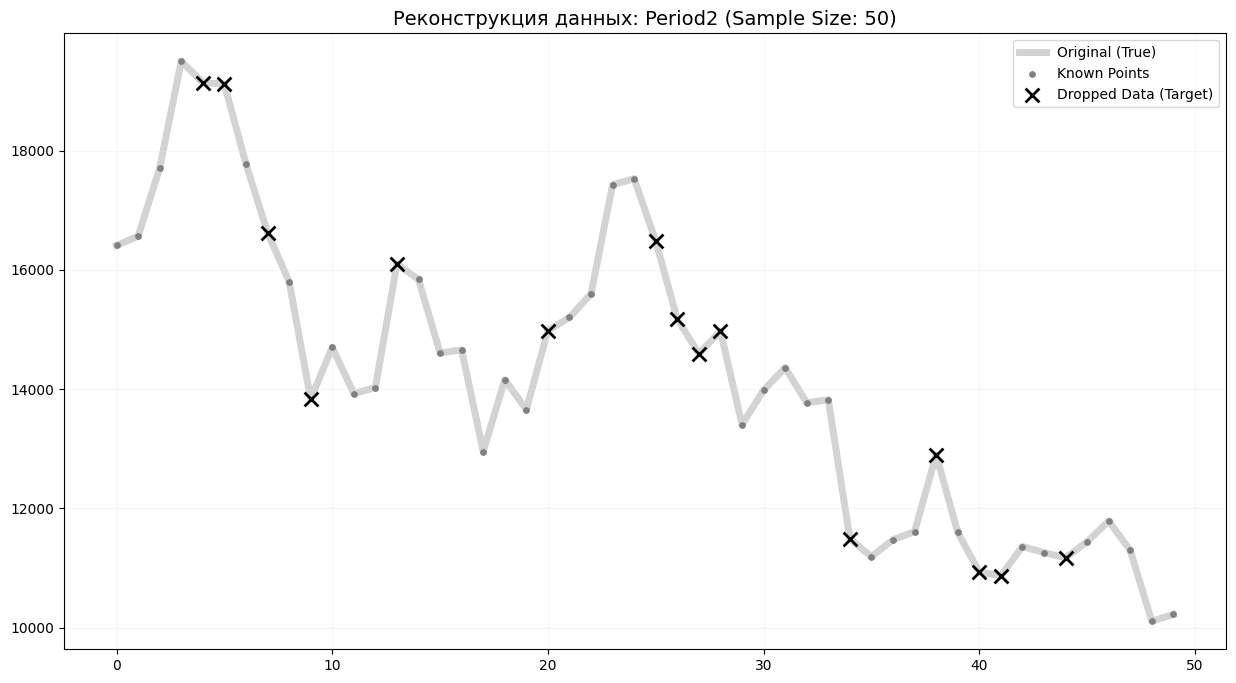

Загрузка Period2: с 2017-09-01 по 2018-02-01...
Загрузка Period2: с 2017-09-01 по 2018-02-01...


/tmp/ipykernel_170/461179823.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', start=start_dt, end=end_dt, progress=False)
/tmp/ipykernel_170/461179823.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', start=start_dt, end=end_dt, progress=False)


Загрузка Period2: с 2017-09-01 по 2018-02-01...
Загрузка Period2: с 2017-09-01 по 2018-02-01...


/tmp/ipykernel_170/461179823.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', start=start_dt, end=end_dt, progress=False)
/tmp/ipykernel_170/461179823.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', start=start_dt, end=end_dt, progress=False)


Загрузка Period2: с 2017-09-01 по 2018-02-01...
Загрузка Period2: с 2017-09-01 по 2018-02-01...
Загрузка Period2: с 2017-09-01 по 2018-02-01...
Загрузка Period2: с 2017-09-01 по 2018-02-01...


/tmp/ipykernel_170/461179823.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', start=start_dt, end=end_dt, progress=False)
/tmp/ipykernel_170/461179823.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', start=start_dt, end=end_dt, progress=False)
/tmp/ipykernel_170/461179823.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', start=start_dt, end=end_dt, progress=False)
/tmp/ipykernel_170/461179823.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', start=start_dt, end=end_dt, progress=False)


   n_missing  RMSE_linear  MAX_ERROR_linear  RMSE_spline  MAX_ERROR_spline  \
0          5   465.768764        979.400065   730.657414       1531.235132   
1         10   721.130569       1295.450195   698.358572       1409.173617   
2         15   777.447468       1419.250488   795.383607       1452.264039   
3         20   858.947618       1879.900065   835.242601       1664.679215   
4         25   804.343659       1879.900065   764.764749       1771.276246   
5         30   876.648186       1833.649902  1011.647371       2270.289905   
6         35  1300.980179       3316.188232  1038.721030       2251.784797   
7         40  1447.393675       3316.188232  1425.907294       3672.705247   

     RMSE_poly  MAX_ERROR_poly  
0   678.137462     1411.835355  
1   845.597108     1675.517622  
2   965.290213     1765.863673  
3   941.716917     1730.473676  
4   954.916665     2146.440740  
5   916.429134     1702.885955  
6  3090.300904    10099.733489  
7  4651.028718    14872.951688  


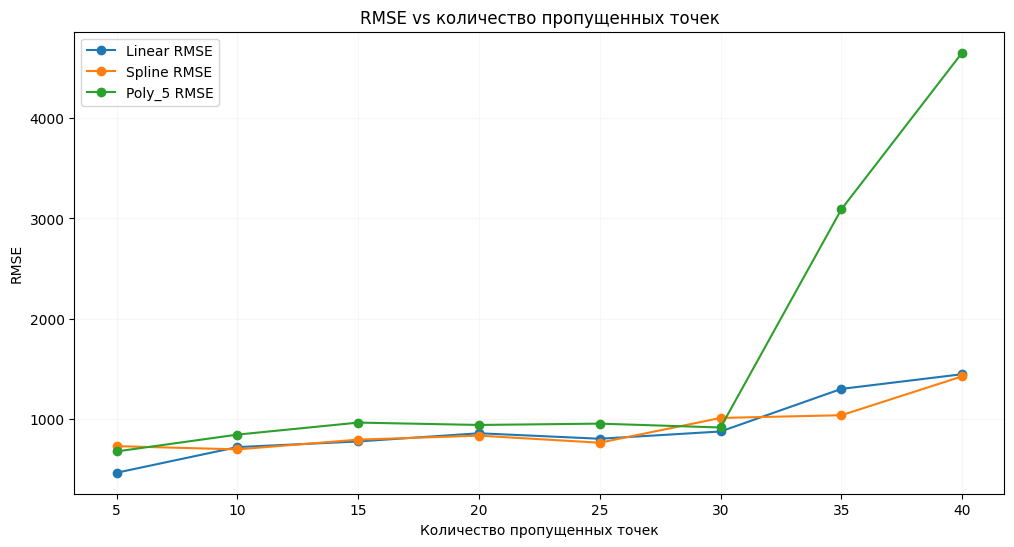

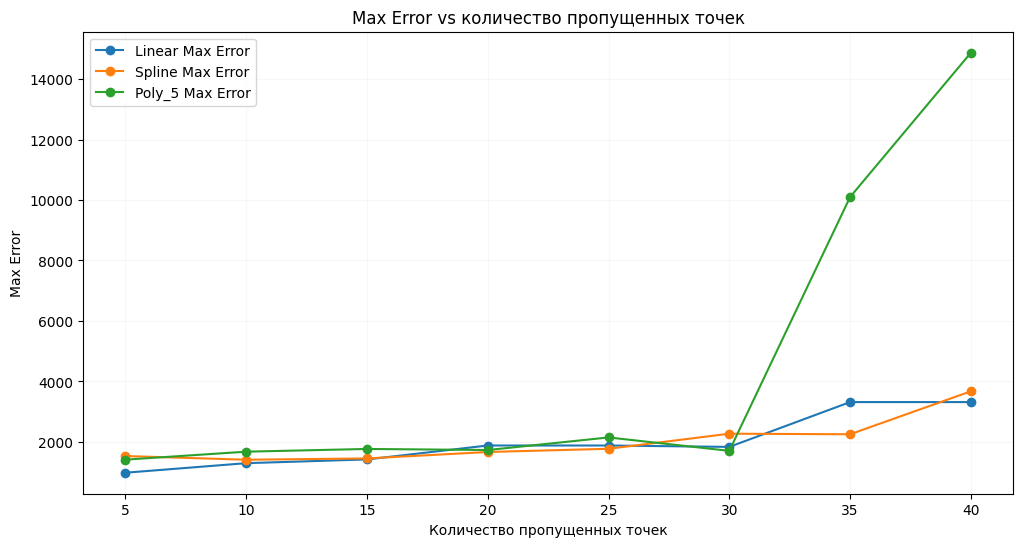

In [ ]:
# не забудьте скачать все библиотеки (!pip install)
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, max_error
import scipy as interpolate
from sklearn.metrics import mean_squared_error
from numpy import sqrt

# Настройки графиков
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'grid.color': '#E6E6E6'})

# БЛОК 1: ПОДГОТОВКА ДАННЫХ (НЕ МЕНЯТЬ)

MY_SCENARIOS = {
    'Period1': ('2018-08-01', '2018-11-10'),
    'Period2': ('2017-09-01', '2018-02-01')
}


def prepare_data_and_sabotage(variant, scenarios_dict, n_missing, sample_size=None, seed=42):
    """
    variant: 'Period1' или 'Period2'
    n_missing: количество точек для удаления
    sample_size: сколько последних точек периода взять (None = весь период)
    """
    start_dt, end_dt = scenarios_dict[variant]

    print(f"Загрузка {variant}: с {start_dt} по {end_dt}...")
    data = yf.download('BTC-USD', start=start_dt, end=end_dt, progress=False)

    if data.empty:
        raise ValueError("Данные не скачались!")

    df = data.reset_index()[['Close']].rename(columns={'Close': 'Original'})

    # Обрезка по размеру выборки, если указано
    if sample_size is not None:
        df = df.tail(sample_size).reset_index(drop=True)

    # Саботаж
    np.random.seed(seed)
    df_work = df.copy()
    drop_idx = np.random.choice(df.index[1:-1], size=n_missing, replace=False)

    df_work['Corrupted'] = df_work['Original']
    df_work.loc[drop_idx, 'Corrupted'] = np.nan

    mask = df_work['Corrupted'].isna()
    return df_work, mask, drop_idx


# БЛОК 2: ВАШЕ исследование

# инициализация (меняйте значения этих трех переменных)
CASE = 'Period2'
N_DROPPED = 15
S_SIZE = 50  # например: попробуйте поменять на 50 или оставить None

df, missing_mask, dropped_indices = prepare_data_and_sabotage(
    CASE, MY_SCENARIOS, n_missing=N_DROPPED, sample_size=S_SIZE
)

# КОД ниже можно менять координально, если нужно

# интерполяция (Задание)
# Реализуйте заполнение пропусков в df['Linear'], df['Spline'] и df['Poly_5']

# Подсказка: 1. Линейная интерполяция используйте метод method='linear' Код: df['column'].interpolate(method='linear')
# Почему: В библиотеке Pandas это самый стабильный алгоритм. Он не требует дополнительных настроек и корректно работает даже на краях данных.
# 2. Кубический сплайн (Для сравнения) используйте методы method='spline' или method='cubic'. Код: df['column'].interpolate(method='spline', order=3)
# Важное примечание: Для работы этого метода в Python должна быть установлена библиотека Scipy (pip install scipy), так как Pandas обращается к ней для сложных математических расчетов.
# для Spline и Poly используйте метод 'spline' или 'polynomial' с указанием order
df['Linear'] = df['Corrupted'].interpolate(method='linear')
df['Spline'] = df['Corrupted'].interpolate(method='spline', order=3)
df['Poly_5'] = df['Corrupted'].interpolate(method='spline', order=5)

# Визуализация (Задание)
plt.figure(figsize=(15, 8))

# Слой 1: истинная цена (фон) (можно менять)
plt.plot(df.index, df['Original'], color='lightgray', linewidth=5, label='Original (True)', zorder=1)

# Слой 2: известные данные (точки) (можно менять)
plt.scatter(df.index, df['Corrupted'], color='gray', s=15, label='Known Points', zorder=2)

# Слой 3: интерполяции (линии)
# Отрисуйте все три метода: Linear (blue), Spline (red, dashed), Poly_5 (green, dotted)
# ... Ваш код здесь ...

# Слой 4: Потерянные данные (крестики) (можно менять)
plt.scatter(dropped_indices, df.loc[dropped_indices, 'Original'],
            color='black', marker='x', s=100, linewidth=2, label='Dropped Data (Target)', zorder=10)

# можно менять
plt.title(f"Реконструкция данных: {CASE} (Sample Size: {S_SIZE})", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Метрики (задание)
# Рассчитайте RMSE и Max Error для каждого метода
# Постройте линейных график этих метрик
# ВАЖНО: Считайте ошибки ТОЛЬКО в точках из missing_mask!

original_in_missing = df.loc[missing_mask, 'Original']

restored_linear = df.loc[missing_mask, 'Linear']
RMSE_linear = np.sqrt(mean_squared_error(original_in_missing, restored_linear))
MAX_ERROR_linear = max_error(original_in_missing, restored_linear)

restored_spline = df.loc[missing_mask, 'Spline']
RMSE_spline = np.sqrt(mean_squared_error(original_in_missing, restored_spline))
MAX_ERROR_spline = max_error(original_in_missing, restored_spline)

restored_poly = df.loc[missing_mask, 'Poly_5']
RMSE_poly = np.sqrt(mean_squared_error(original_in_missing, restored_poly))
MAX_ERROR_poly = max_error(original_in_missing, restored_poly)

results = []

for miss in range(5, 41, 5):
    df, missing_mask, dropped_indices = prepare_data_and_sabotage(
        CASE, MY_SCENARIOS, n_missing=miss, sample_size=S_SIZE
    )

    df['Linear'] = df['Corrupted'].interpolate(method='linear')
    df['Spline'] = df['Corrupted'].interpolate(method='spline', order=3)
    df['Poly_5'] = df['Corrupted'].interpolate(method='spline', order=5)

    original_in_missing = df.loc[missing_mask, 'Original']

    restored_linear = df.loc[missing_mask, 'Linear']
    RMSE_linear = np.sqrt(mean_squared_error(original_in_missing, restored_linear))
    MAX_ERROR_linear = max_error(original_in_missing, restored_linear)

    restored_spline = df.loc[missing_mask, 'Spline']
    RMSE_spline = np.sqrt(mean_squared_error(original_in_missing, restored_spline))
    MAX_ERROR_spline = max_error(original_in_missing, restored_spline)

    restored_poly = df.loc[missing_mask, 'Poly_5']
    RMSE_poly = np.sqrt(mean_squared_error(original_in_missing, restored_poly))
    MAX_ERROR_poly = max_error(original_in_missing, restored_poly)

    dict_frame = {
        "n_missing": miss,
        "RMSE_linear": RMSE_linear,
        "MAX_ERROR_linear": MAX_ERROR_linear,
        "RMSE_spline": RMSE_spline,
        "MAX_ERROR_spline": MAX_ERROR_spline,
        "RMSE_poly": RMSE_poly,
        "MAX_ERROR_poly": MAX_ERROR_poly
    }

    results.append(dict_frame)

results_df = pd.DataFrame(results)
print(results_df)

plt.figure(figsize=(12, 6))
plt.plot(results_df['n_missing'], results_df['RMSE_linear'], marker='o', label='Linear RMSE')
plt.plot(results_df['n_missing'], results_df['RMSE_spline'], marker='o', label='Spline RMSE')
plt.plot(results_df['n_missing'], results_df['RMSE_poly'], marker='o', label='Poly_5 RMSE')
plt.xlabel('Количество пропущенных точек')
plt.ylabel('RMSE')
plt.title('RMSE vs количество пропущенных точек')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(results_df['n_missing'], results_df['MAX_ERROR_linear'], marker='o', label='Linear Max Error')
plt.plot(results_df['n_missing'], results_df['MAX_ERROR_spline'], marker='o', label='Spline Max Error')
plt.plot(results_df['n_missing'], results_df['MAX_ERROR_poly'], marker='o', label='Poly_5 Max Error')
plt.xlabel('Количество пропущенных точек')
plt.ylabel('Max Error')
plt.title('Max Error vs количество пропущенных точек')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


1. В Period2 данные выглядят более волатильными: на графике есть резкие изменения цены и развороты. В таких условиях простые методы ведут себя стабильнее, а более сложные (сплайн, полином) могут давать сильные отклонения

2. Максимальное отклонение у сплайна в одном из экспериментов получилось огромным — около 1.7⋅10^8 долларов. Это нереалистичное значение для цены BTC и показывает, что алгоритм может “галлюцинировать”. В реальной торговле такая ошибка могла бы привести к ложным сигналам и большим убыткам, особенно при использовании кредитного плеча

3. На резких разворотах цены сплайн и полином могут “перелетать” через реальные значения. Они иногда рисуют цену выше реального пика или ниже реального минимума, тогда как линейная интерполяция просто соединяет соседние точки и не создаёт таких сильных выбросов

4. На краях данных у полинома и сплайна меньше информации о соседних точках, поэтому их поведение становится менее надёжным. Без точек с обеих сторон они могут сильнее отклоняться от реальной цены. Линейная интерполяция в таких местах обычно ведёт себя стабильнее

5. Возможно, что средняя ошибка (RMSE) у сплайна ниже, чем у линейного метода, но торговать по таким данным всё равно опаснее. RMSE показывает среднюю ошибку, а в трейдинге важнее учитывать максимальную ошибку (Max Error), потому что один сильный выброс может привести к большим потерям

6. Использование более сложных методов не всегда оправдано. В этом эксперименте линейная интерполяция даёт сопоставимую точность и при этом не создаёт экстремальных выбросов, поэтому она выглядит более надёжной

7. На коротких отрезках данных сложные методы обычно работают хуже, потому что у них меньше информации для построения кривой. Полиномы и сплайны могут сильнее переизгибаться, поэтому ошибки могут увеличиваться

8. На коротких отрезках данных сложные методы обычно работают хуже, потому что у них меньше информации для построения кривой. Полиномы и сплайны могут сильнее переизгибаться, поэтому ошибки могут увеличиваться

<a name="task_2"></a>
**<font color=#FF5EDD>Задача 2**</font>

Вы — ведущий архитектор безопасности в мегакорпорации "Arasaka Corp". В главном хранилище лежит код активации ии-ящика "Омега" (число *42_000*). Чтобы один безумный топ-менеджер не мог активировать ии-ящик Омега в одиночку, а уборщица случайно не удалила базу данных, Вы внедрили криптографическую систему разделения ключа.

*иерархия доступа* (всего *20* сотрудников):
1. CEO (Гендиректор): владеет Мастер-ключом (эквивалентен 5 обычным осколкам).
2. CTO и CFO (Топ-менеджмент): имеют Золотые ключи (по 3 осколка каждый).
3. Senior Devs (Сеньоры): имеют Серебряные ключи (по 2 осколка).
4. Interns (Стажеры): имеют Бронзовые ключи (по 1 осколку).

*Параметры безопасности:*

Чтобы активировать ящик, нужно собрать суммарную мощность 12 единиц (Threshold $k=12$). Меньше 12 — код не поддается взлому (перебор бесполезен).

<font color=#FF5EDD>***Задача 1: Архитектура***</font>

Реализуйте класс `OmegaProtocol`, который:
* Генерирует полином степени $k-1$, где $f(0) = Secret$.
* Раздает осколки (координаты $x, y$) сотрудникам в зависимости от их роли.  
Подсказка: Если у CEO вес 5, выдайте ему 5 разных точек (например, $x=1, x=2, x=3, x=4, x=5$). Следующему сотруднику выдавайте точки, начиная с 6.

<font color=#FF5EDD>***Задача 2: Моделирование ситуаций***</font>

Напишите скрипт, проверяющий три сценария:
1. "*Бунт стажеров*": Все стажеры (5 человек) и один Сеньор пытаются открыть сейф. Хватит ли им власти?
2. "*Корпоративный переворот*": CEO в отпуске. Смогут ли CTO + CFO + 2 Сеньора запустить систему без него?
3. "*Одинокий волк*": Может ли CEO запустить систему в одиночку?

<font color=#FF5EDD>***Задача 3: Визуализация***</font>

Постройте график, на котором:
* Зеленая линия: Успешное восстановление (когда $N \ge 12$).
* Красный "Веер": Если $N < 12$, нарисуйте 20-30 полупрозрачных серых линий, которые проходят через точки заговорщиков, но бьют в совершенно разные значения Секрета. Цель: Наглядно показать, что при нехватке даже 1 осколка, секретом может быть любое число.

<font color=#FF5EDD>**Вопросы:**</font>

1.Экономика атаки: Сколько минимум сотрудников нужно подкупить злоумышленнику, чтобы украсть секрет, если CEO недоступен? Найдите самую дешевую комбинацию (допустим, подкуп стажера стоит $1k$, а сеньора $5k$).

2. Устойчивость: Если один из стажеров потеряет свой ключ (забыл на столе), станет ли система неработоспособной? Сколько ключей можно потерять безвозвратно, чтобы компания всё ещё могла открыть сейф?

3. Представьте, что Сеньоры собрали кворум (12 единиц), но один из них — предатель. Он передал свою пару $(x, y)$ с небольшой ошибкой (изменил $y$ на 0.001). Что произойдет с восстановленным секретом: он будет немного отличаться от истинного или станет абсолютно другим случайным числом?

4. Один из стажеров был уволен и унес свой "Бронзовый ключ" домой. Чтобы обезопасить компанию, нужно сменить код активации Омеги. Нужно ли выдавать новые ключи всем остальным 19 сотрудникам? или можно как-то "отменить" только ключ стажера?




--- Сценарий 1: Бунт ---


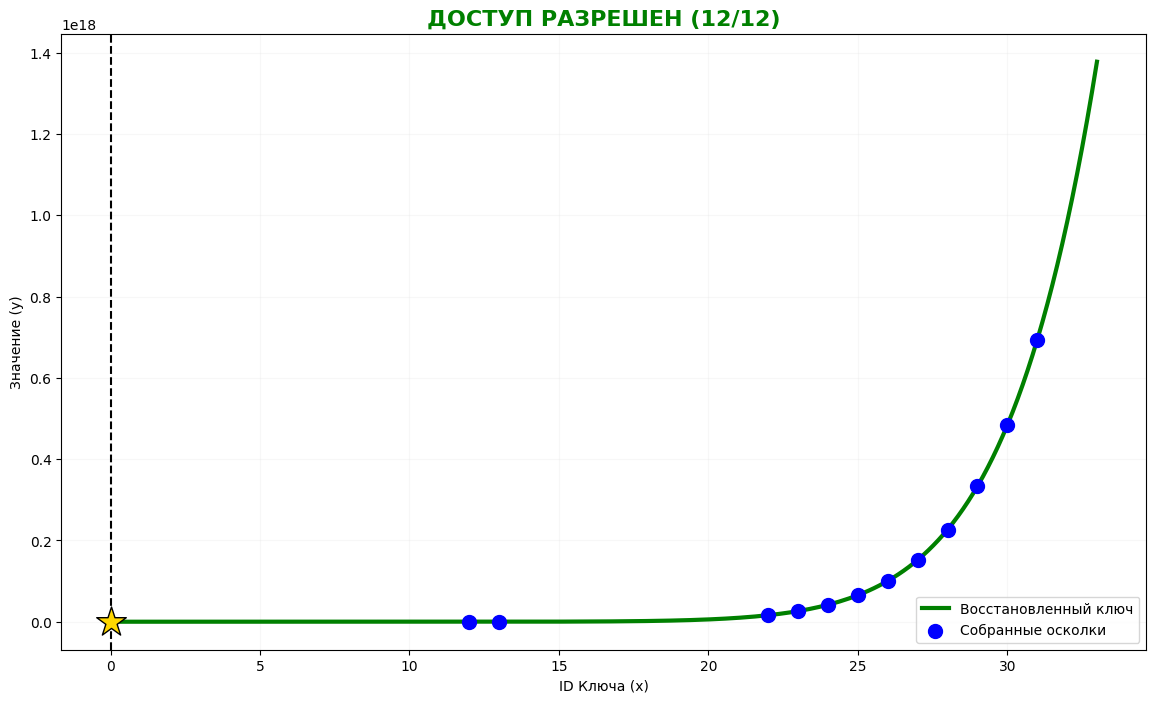


--- Сценарий 2: CEO один ---
Взлом... Не хватает 7 ключей. Генерируем фантомы.


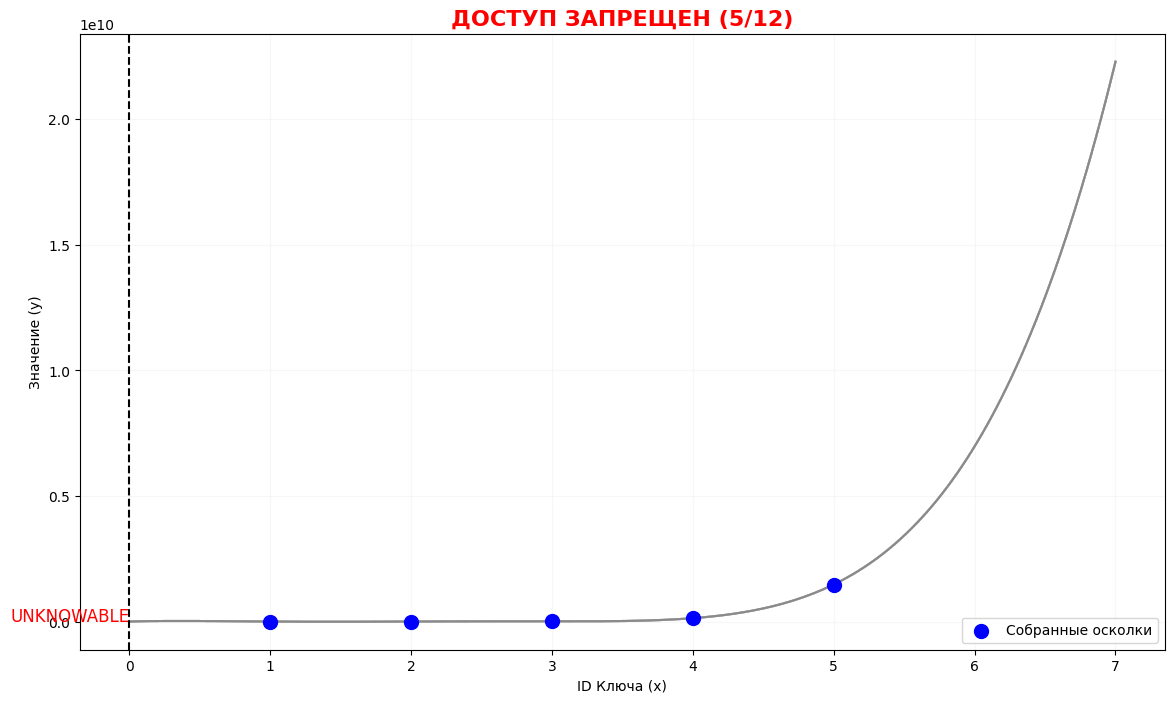


--- Сценарий 3: Переворот (11 из 12) ---
Взлом... Не хватает 1 ключей. Генерируем фантомы.


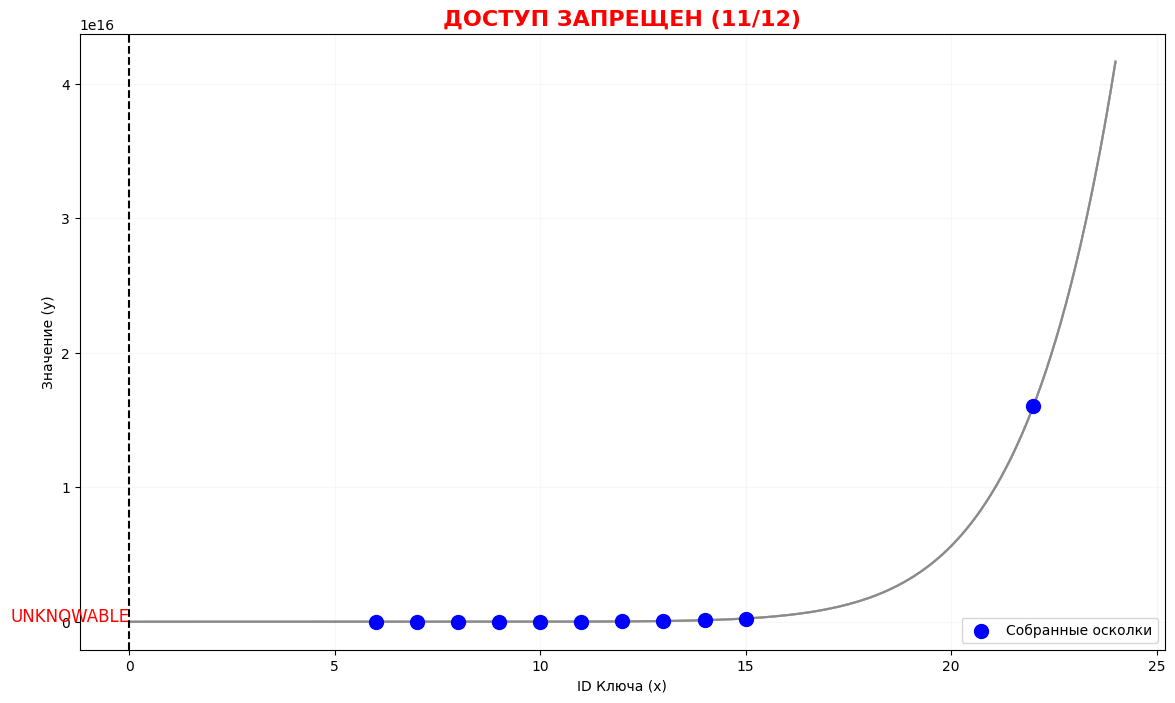

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange
from numpy.polynomial.polynomial import Polynomial
import random

# Настройки стиля
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'grid.color': '#E6E6E6'})


# БЛОК 1: ядро безопасности (задание 1)

class OmegaProtocol:
    def __init__(self, secret, threshold):
        self.secret = secret
        self.k = threshold

        coeffs = [random.randint(1, 50) for _ in range(self.k - 1)]
        coeffs.append(self.secret)
        self.poly = np.poly1d(coeffs)
        self.current_x_index = 1

    def issue_keys(self, role_name, weight, count_people):
        """
        Выдает ключи группе людей.
        role_name: название роли (например, "CEO")
        weight: сколько точек (осколков) получает один человек этой роли
        count_people: сколько людей в этой роли
        """
        issued = {}
        for i in range(1, count_people + 1):
            person_id = f"{role_name}_{i}"
            keys = []

            # --- ВАШ КОД ЗДЕСЬ (Раздача ключей) ---
            for _ in range(weight):
                x = self.current_x_index
                y = self.poly(x)
                keys.append((x, y))
                self.current_x_index += 1
            # Цикл должен выполниться 'weight' раз.
            # На каждой итерации:
            #   1. Берем текущий x (self.current_x_index)
            #   2. Вычисляем y = self.poly(x)
            #   3. Добавляем (x, y) в список keys
            #   4. Увеличиваем self.current_x_index на 1

            # ...

            issued[person_id] = keys
        return issued


# БЛОК 2: логика взлома и визуализация (задание 2)

def attempt_activation(protocol, coalition_keys):
    """
    protocol: экземпляр класса OmegaProtocol
    coalition_keys: плоский список ключей [(x1,y1), (x2,y2)...] всех собравшихся
    """
    # 1. Распаковка данных
    if not coalition_keys:
        print("Нет ключей!")
        return

    x_shares = np.array([k[0] for k in coalition_keys])
    y_shares = np.array([k[1] for k in coalition_keys])
    total_power = len(x_shares)  # Мощность собранной коалиции

    plt.figure(figsize=(14, 8))

    # Область отрисовки (по оси X)
    x_plot = np.linspace(0, max(x_shares) + 2, 200)

    # --- ВЕТКА 1: НЕДОСТАТОЧНО ПРАВ (FAIL) ---
    if total_power < protocol.k:
        status = f"ДОСТУП ЗАПРЕЩЕН ({total_power}/{protocol.k})"
        color_status = "red"

        print(f"Взлом... Не хватает {protocol.k - total_power} ключей. Генерируем фантомы.")

        # --- ВАШ КОД ЗДЕСЬ (Визуализация неопределенности) ---
        # Задача: Показать, что секретом может быть ЧТО УГОДНО.
        # Цикл 20 раз:
        for _ in range(20):
            fake_secret = random.randint(int(protocol.secret * 0.5), int(protocol.secret * 1.5))
            x_temp = np.append(x_shares, 0)
            y_temp = np.append(y_shares, fake_secret)

            coeffs = np.polyfit(x_temp, y_temp, deg=len(x_temp) - 1)
            fake_poly = np.poly1d(coeffs)

            plt.plot(x_plot, fake_poly(x_plot), color='gray', alpha=0.1)

        #   1. Придумайте fake_secret (случайное число в диапазоне secret +/- 50%)
        #   2. Добавьте точку (0, fake_secret) к массивам x_shares, y_shares
        #   3. Постройте интерполяционный полином через эти точки (np.polyfit степени len-1)
        #   4. Нарисуйте линию (plt.plot) серым цветом (alpha=0.1)

        # ...

        plt.text(0, protocol.secret, "UNKNOWABLE", fontsize=12, color='red', ha='right')

    # --- ВЕТКА 2: ДОСТАТОЧНО ПРАВ (SUCCESS) ---
    else:
        status = f"ДОСТУП РАЗРЕШЕН ({total_power}/{protocol.k})"
        color_status = "green"

        # --- ВАШ КОД ЗДЕСЬ (Восстановление) ---
        # 1. используйте lagrange из scipy.interpolate
        # 2. Важно: передайте в lagrange ТОЛЬКО первые k точек (protocol.k)
        # 3. Преобразуйте результат в Polynomial и вычислите значения для x_plot

        x_used = x_shares[:protocol.k]
        y_used = y_shares[:protocol.k]

        poly_lagrange = lagrange(x_used, y_used)
        poly_lagrange = Polynomial(poly_lagrange.coefficients[::-1])

        y_recon = poly_lagrange(x_plot)

        plt.plot(x_plot, y_recon, color='green', linewidth=3, label='Восстановленный ключ')
        plt.scatter(0, protocol.secret, s=500, marker='*', color='gold', edgecolors='black', zorder=10)

    # Оформление графика
    plt.scatter(x_shares, y_shares, s=100, color='blue', zorder=5, label=f'Собранные осколки')
    plt.title(status, fontsize=16, color=color_status, fontweight='bold')
    plt.axvline(0, color='black', linestyle='--')
    plt.xlabel("ID Ключа (x)");
    plt.ylabel("Значение (y)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# БЛОК 3: сценарии (ЗАПУСК)

# инициализация (Секрет = 42000, Порог = 12)
# Важно: Код упадет здесь, если вы не реализовали __init__ класса!
try:
    OMEGA = OmegaProtocol(secret=42000, threshold=12)
except Exception as e:
    print(f"Ошибка инициализации: {e}")
    exit()

# Раздача ключей
ceo_keys = OMEGA.issue_keys("CEO", weight=5, count_people=1)
top_keys = OMEGA.issue_keys("TopMngr", weight=3, count_people=2)
sen_keys = OMEGA.issue_keys("Senior", weight=2, count_people=5)
int_keys = OMEGA.issue_keys("Intern", weight=1, count_people=10)

# --- сценарий 1: БУНТ СТАЖЕРОВ ---
# 10 Стажеров (10) + 1 Сеньор (2) = 12. (Должен быть УСПЕХ)
print("\n--- Сценарий 1: Бунт ---")
rebels = []
for k in int_keys.values(): rebels.extend(k)
rebels.extend(sen_keys["Senior_1"])

attempt_activation(OMEGA, rebels)

# --- сценарий 2: одинокий ВОЛК ---
# Только CEO (5). (Должен быть ПРОВАЛ + Веер линий)
print("\n--- Сценарий 2: CEO один ---")
wolf_pack = []
wolf_pack.extend(ceo_keys["CEO_1"])

attempt_activation(OMEGA, wolf_pack)

# --- сценарий 3: совет директоров (БЕЗ CEO) ---
# 2 Топа (6) + 2 Сеньора (4) + 1 Стажер (1) = 11. (Должен быть ПРОВАЛ)
# Обратите внимание, как близко линии подойдут к секрету, но не совпадут!
print("\n--- Сценарий 3: Переворот (11 из 12) ---")
board = []
for k in top_keys.values(): board.extend(k)
board.extend(sen_keys["Senior_1"])
board.extend(sen_keys["Senior_2"])
board.extend(int_keys["Intern_1"])

attempt_activation(OMEGA, board)

1. Если CEO недоступен, злоумышленнику нужно собрать 12 единиц мощности.
Самая дешевая стратегия — подкупить только стажеров. Каждый стажер дает 1 единицу мощности и стоит 1k. Поэтому минимальная стоимость атаки составляет 12k (12 стажеров)
2. В системе всего 20 сотрудников, а порог восстановления равен 12.
Это означает, что система остается работоспособной, пока существует хотя бы 12 ключей. Следовательно, можно потерять до 8 ключей без потери возможности восстановления секрета
3. Интерполяция полинома чувствительна к ошибкам в данных.
Если хотя бы одна точка (x, y) содержит даже небольшую ошибку, восстановленный полином будет отличаться от исходного. В результате восстановленный секрет может оказаться совершенно другим числом
4. Интерполяция полинома чувствительна к ошибкам в данных.
Если хотя бы одна точка (x, y) содержит даже небольшую ошибку, восстановленный полином будет отличаться от исходного.
В результате восстановленный секрет может оказаться совершенно другим числом

<a name="function_several_variables"></a>
## **<font color=#FF6100>2. Раздел: функции нескольких переменных**

In [ ]:
import numpy as np
from numpy import pi as Pi_, cos as Cos_, sin as Sin_, exp as Exp_, sqrt as Sqrt_, log as Log_, arccos as Arccos_, tan as Tan_, arctan as Atan_, arcsin as Asin_
import matplotlib.pyplot as plt
import math
import plotly.graph_objects as go
import sympy as sp
from sympy import Symbol, symbols, diff, solve, Eq, nsolve, solveset, integrate, Integral, Function, latex, S, simplify, fraction, Union, Interval, intersection, limit, plot, Piecewise, Curve, plot_parametric, plot_implicit, And, nonlinsolve, Matrix, factor, lambdify
from sympy.calculus.util import continuous_domain
from sympy.plotting import plot3d
from sympy.geometry import Point
from sympy import sin as Sin, cos as Cos, tan as Tan, exp as Exp, log as Log, pi as Pi, sqrt as Sqrt, asin as Asin, atan as Atan, oo as Infinity, acos as Acos
%matplotlib inline

<a name="function_several_variables_1_part"></a>
### <font color=#FF6100>Область определения, предел и непрерывность, приращение и дифференциал

<a name="task_3"></a>
**<font color=#FF5EDD>Задача 3**</font>

Вы выступаете в роли аудитора DeFi-протокола.

Разработчики заявляют, что при минимизации издержек сети (комиссии $g$ и времени блока $t$) эффективность системы стремится к максимуму ($100\%$). Однако архитектура протоколов в многомерном пространстве параметров часто таит в себе неопределенности. Вам необходимо проверить, является ли предел эффективности стабильным или он зависит от стратегии масштабирования сети.

Математическая модель: Функция эффективности протокола (Efficiency Score) задана уравнением:$$E(g, t) = (\cos g)^{\frac{1}{t^2}}$$Где:$g$ — средняя стоимость газа (Gas price), $g \to 0$.$t$ — время финализации блока (Time to finality), $t \to 0$.

*Задание 1: Проверка на устойчивость (Повторные пределы)*

Прежде чем запускать масштабный тест, необходимо проверить, как ведет себя система при поочередном изменении параметров.
* Вычислите предел функции при условии, что комиссия уже обнулена ($g = 0$), а время блока $t$ стремится к 0.
* Вычислите предел функции при фиксированном времени блока ($t = const$), если комиссия $g$ стремится к 0.
* Вопрос: Можно ли на основе этих данных утверждать, что общая эффективность всегда будет равна 1?

*Задание 2: масштабирование*

Предположим, что обновление сети происходит пропорционально: комиссия падает линейно в зависимости от скорости сети.Введем зависимость $g = k \cdot t$, где $k > 0$ — коэффициент пропорциональности. С помощью SymPy, вычислите предел:$$\lim_{t \to 0} E(kt, t)$$Анализ: Как значение коэффициента $k$ влияет на итоговый результат? Рассчитайте конкретные значения эффективности для $k = 1$ и $k = 3$.

*Задание 3: Моделирование сценария «L2 Scaling»*

Рассмотрим ситуацию, когда технологический апгрейд позволил радикально уменьшить время блока, но оптимизация комиссий за ним не поспевает.
* Найдите предел эффективности в случае, если комиссия затухает медленнее, чем время блока, по закону $g = \sqrt{t}$.
* Сформулируйте математический вывод: к чему придет протокол при таком сценарии масштабирования?

In [ ]:
# Задание 1

from sympy import symbols, cos, sqrt, limit
g, k, t = symbols('g k t')
E = cos(g)**(1/t**2)

E_g0 = E.subs(g, 0)
result_Eg0 = limit(E_g0, t, 0)
result_E = limit(E, g, 0)
print(result_Eg0)
print(result_E)

1
1


Если сначала положить g=0, то cos0=1, поэтому функция равна 1 при любом t и предел равен 1. Если взять предел при g->0 при фиксированном t, то cosg->1, и получаем 1. Однако, из этого нельзя сделать вывод, что общий предел функции всегда равен 1

In [ ]:
# Задание 2
E_kt = E.subs(g, k*t)
result_E_kt = limit(E_kt, t, 0)

result_k1 = result_E_kt.subs(k, 1)
result_k3 = result_E_kt.subs(k, 3)

print(result_E_kt)
print(result_k1)
print(result_k3)

exp(-k**2/2)
exp(-1/2)
exp(-9/2)


При подстановке g=kt предел функции зависит от коэффициента k и равен exp(-k**2/2). Для k=1 получаем exp(-1/2), для k=3 получаем exp(-9/2). Значит, результат зависит от пути, по которому g и t стремятся к нулю

In [ ]:
# Задание 3
E_sqrt = E.subs(g, sqrt(t))
result_E_sqrt = limit(E_sqrt, t, 0)
print(result_E_sqrt)


0


Предел функции равен 0. Это показывает, что эффективность может стремиться к разным значениям. Следовательно, общего предела функции в точке (0,0) не существует.

<a name="task_4"></a>
**<font color=#FF5EDD>Задача 4**</font>

*Уровень пыльцы*

В тихом и уютном городке под названием «Долина математиков» раскинулся плодовый сад. Координаты его — $(0,0)$, то есть прямо в центре мира (по мнению местных пчёл). С наступлением весны здесь происходит настоящее буйство цветения, а вместе с ним — и великое нашествие пыльцы.

Математик Аркадий, вдохновлённый не только красотой природы, но и мощным чиханием, вывел формулу, которая описывает пыльцевой индекс — показатель того, насколько сильно здесь может заложить нос:

$$
f(x, y) = \frac{\sin(y x)}{x^2 + y^2}
$$

- Здесь $(x, y)$ — это Ваши координаты.
- Числитель отражает таинственные колебания пыльцевого потока, зависящие от того, как именно Вы отклонились от центра.
- В знаменателе — $x^2 + y^2$, и он напоминает нам, что чем дальше вы убегаете от сада, тем больше пыльца начинает лениться и оседать.

Но есть одно но: в самом центре — в точке $(0,0)$ — происходит что-то загадочное. Формула там *не определена* — ведь мы получаем $\tfrac{0}{0}$, математическую версию «мы не уверены, но возможно произойдёт пыльцевой апокалипсис».

Аркадий решил ответить на волнующий всех чихающих математиков вопрос:  
«А что вообще происходит с пыльцевым индексом *вблизи* центра? Он стремится к чему-то конкретному?»

Помогите Аркадию:)

In [ ]:
from sympy import symbols, sin, limit
x, y = symbols('x y')
f = sin(x*y) / (x**2 + y**2)

f_x = f.subs(y, x)
result_f_x = limit(f_x, x, 0)
print(result_f_x)

f_x2 = f.subs(y, x**2)
result_f_x2 = limit(f_x2, x, 0)
print(result_f_x2)

res_4 = -1000

1/2
0


Вблизи центра значение функции зависит от направления приближения, поэтому единого предела не существует. Следовательно, пыльцевой индекс в точке (0,0) определить нельзя.

<a name="task_5"></a>
**<font color=#FF5EDD>Задача 5**</font>

Вам дана следующая функция:$$
f(x, y) = \sin\left(\frac{x}{y}\right)
$$
1. Построить линии уровня.
2. Найти полный дифференциал функции.

In [ ]:
from sympy import symbols, diff

x, y = symbols('x y')
dx, dy = symbols('dx dy')

# Нельзя менять переменную f_5
f_5 = Sin(x/y)

f_x = diff(f_5, x)
f_y = diff(f_5, y)

answer_5 = f_x*dx + f_y*dy # В эту переменную вместо нуля запишите искомый полный дифференциал

print(answer_5)
# ღゝ◡╹)ノ♡ Ваш код здесь

dx*cos(x/y)/y - dy*x*cos(x/y)/y**2


Линии уровня функции задаются уравнением sin(x/y)=c. Отсюда x/y=arcsin(c)+2πk, поэтому линии уровня представляют собой прямые x=y(arcsin(c)+2πk), проходящие через начало координат